installing pytorch and getting it to run


In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Ready to go!")

PyTorch version: 2.11.0+cpu
Ready to go!


just creating some training data

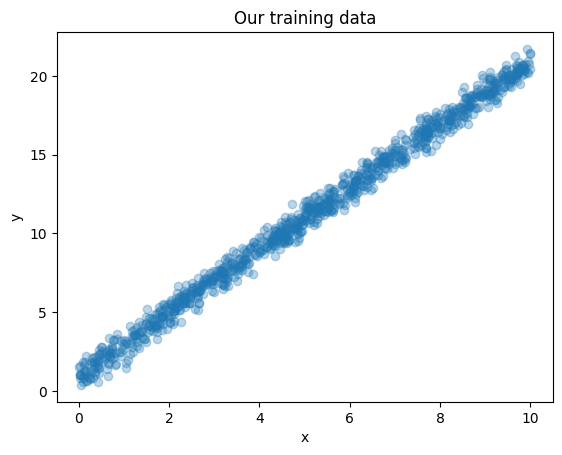

In [7]:
# Create 1000 random x values between 0 and 10
X = torch.FloatTensor(np.random.uniform(0, 10, (1000, 1)))

# Create y values using the rule y = 2x + 1, with a little noise
y = 2 * X + 1 + torch.randn(1000, 1) * 0.5

# Look at the data
plt.scatter(X.numpy(), y.numpy(), alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Our training data")
plt.show()

In [8]:
print("Shape of X:", X.shape)
print("First 3 values:")
print(X[:3])

Shape of X: torch.Size([1000, 1])
First 3 values:
tensor([[1.6517],
        [7.6963],
        [2.9252]])


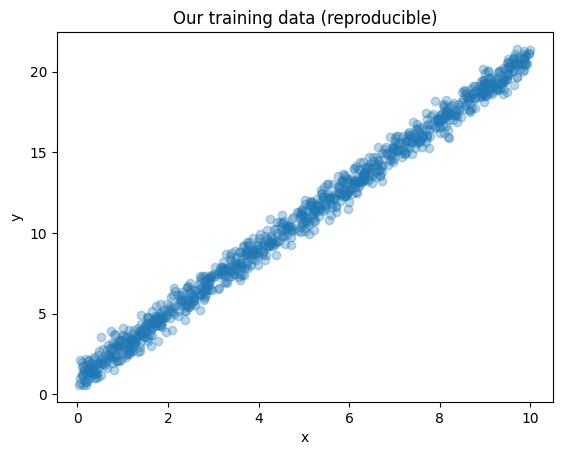

In [9]:
# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Create data
X = torch.FloatTensor(np.random.uniform(0, 10, (1000, 1)))
y = 2 * X + 1 + torch.randn(1000, 1) * 0.5

plt.scatter(X.numpy(), y.numpy(), alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Our training data (reproducible)")
plt.show()

In [10]:
model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)


Stacking linear layers without non-linearity is mathematically equivalent to one linear layer. Algebra proves this.
One linear layer can only output y = mx + b. A straight line.
A straight line can't fit a curve. Fundamentally.
ReLU breaks the collapse because max(0, x) is not a linear function — it's piecewise. Substituting it doesn't simplify away.
The piecewise structure creates a corner ("kink") in the output function.
Many neurons = many corners = approximate any curve.

So the corrected mental model
For a typical NN structure (Linear → ReLU → Linear → ReLU → Linear → output):

Hidden layers: every output dimension = ReLU(linear combination of inputs). Adds a kink to each dimension. 
Final layer: every output dimension = just linear combination of previous layer. No kink at the output. 

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)                # 4. take a step in the negated gradient direction

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


- the optimizer claculates the negative gradient vector, in order to go in the direction which decreases the cost function the most
- lost_fn will calculate the least squares distance currently (how wrong stuff is)
- adam is just another version of gradient descent

In [12]:
losses = []  # to track loss over time

for epoch in range(500):
    pred = model(X)              # forward pass — predictions
    loss = loss_fn(pred, y)      # compute loss
    losses.append(loss.item())   # save loss number for plotting
    
    optimizer.zero_grad()        # reset gradients
    loss.backward()              # compute gradients (backprop)
    optimizer.step()             # update weights
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

print("Training complete!")

Epoch 0, Loss: 135.8569
Epoch 50, Loss: 2.0720
Epoch 100, Loss: 0.2904
Epoch 150, Loss: 0.2635
Epoch 200, Loss: 0.2511
Epoch 250, Loss: 0.2509
Epoch 300, Loss: 0.2509
Epoch 350, Loss: 0.2509
Epoch 400, Loss: 0.2509
Epoch 450, Loss: 0.2509
Training complete!


try to reproduce one mie curve, hold both constant, try reLu and tan h.

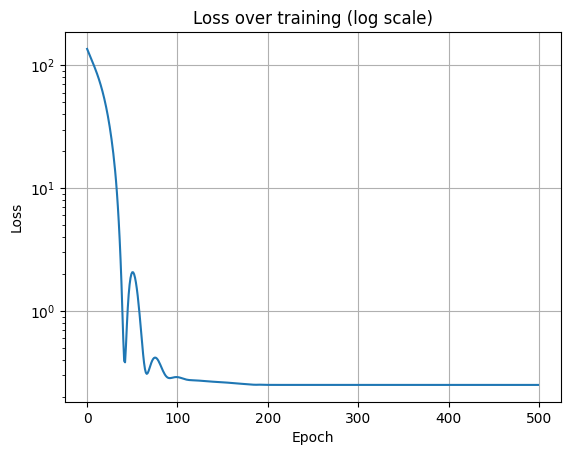

In [13]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over training (log scale)")
plt.yscale('log')   # log scale to see the dramatic drop clearly
plt.grid(True)
plt.show()

graphing the loss

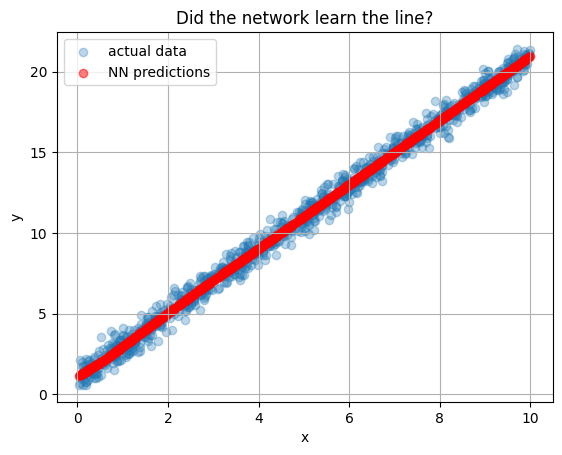

In [14]:
with torch.no_grad():
    predictions = model(X)

plt.scatter(X.numpy(), y.numpy(), label='actual data', alpha=0.3)
plt.scatter(X.numpy(), predictions.numpy(), label='NN predictions', alpha=0.5, color='red')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Did the network learn the line?")
plt.legend()
plt.grid(True)
plt.show()

re-entered the x values and made predictions. Compared the predictions with the actual labels from the training set
